In [1]:
%load_ext autoreload
%autoreload 2

import sys, warnings, glob, datetime
import xwmt, xwmb, xgcm, regionate, xbudget

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion
import seaborn as sns
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import pandas as pd


dpi = 150
mpl.rcParams['figure.dpi'] = dpi
sns.set_theme(context='notebook', style='ticks')

sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *

from SWMT_decomposition import *
from ant_plots import *
from isopycnal_plot_formatting import *
from select_max_loc import *
from spatial_decompostion import *

In [2]:
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budgets_sigma2_1p5/" + x

datafiles = glob.glob(datadir("CM4Xp125*"))[20:]
datafiles = sorted(datafiles)

file = datafiles[0]

ds = xr.open_mfdataset(
        file,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        parallel=True,
        engine="zarr")

ds['mask'] = (
    (ds['geolat'] <= -50)
)

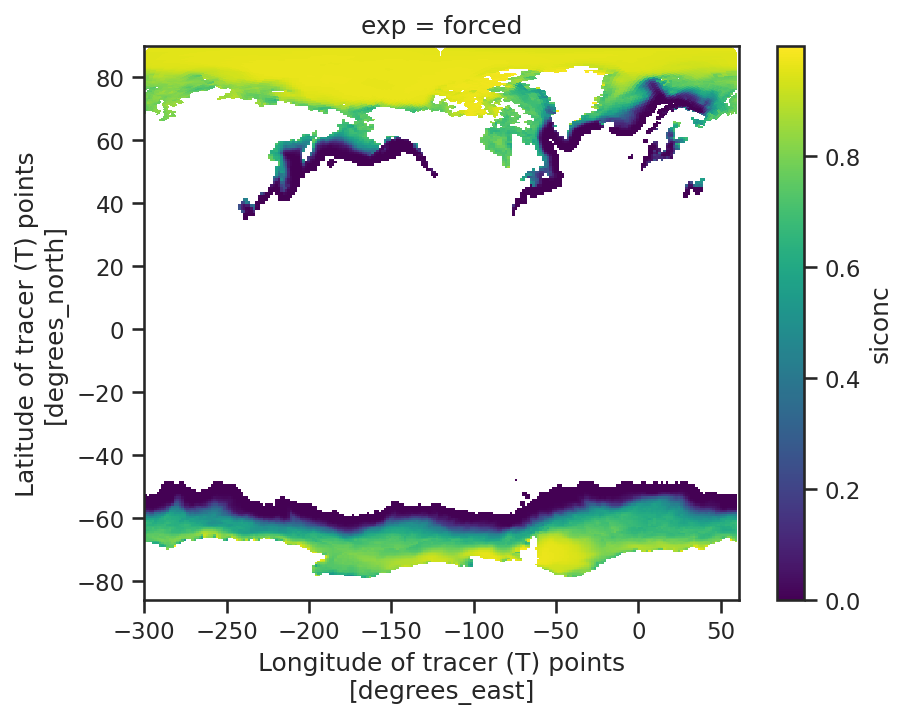

In [3]:
ds["siconc"].groupby("time.year").mean("time").mean("year").isel(exp = 0).plot(x = "geolon", y = "geolat")

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_analysis/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


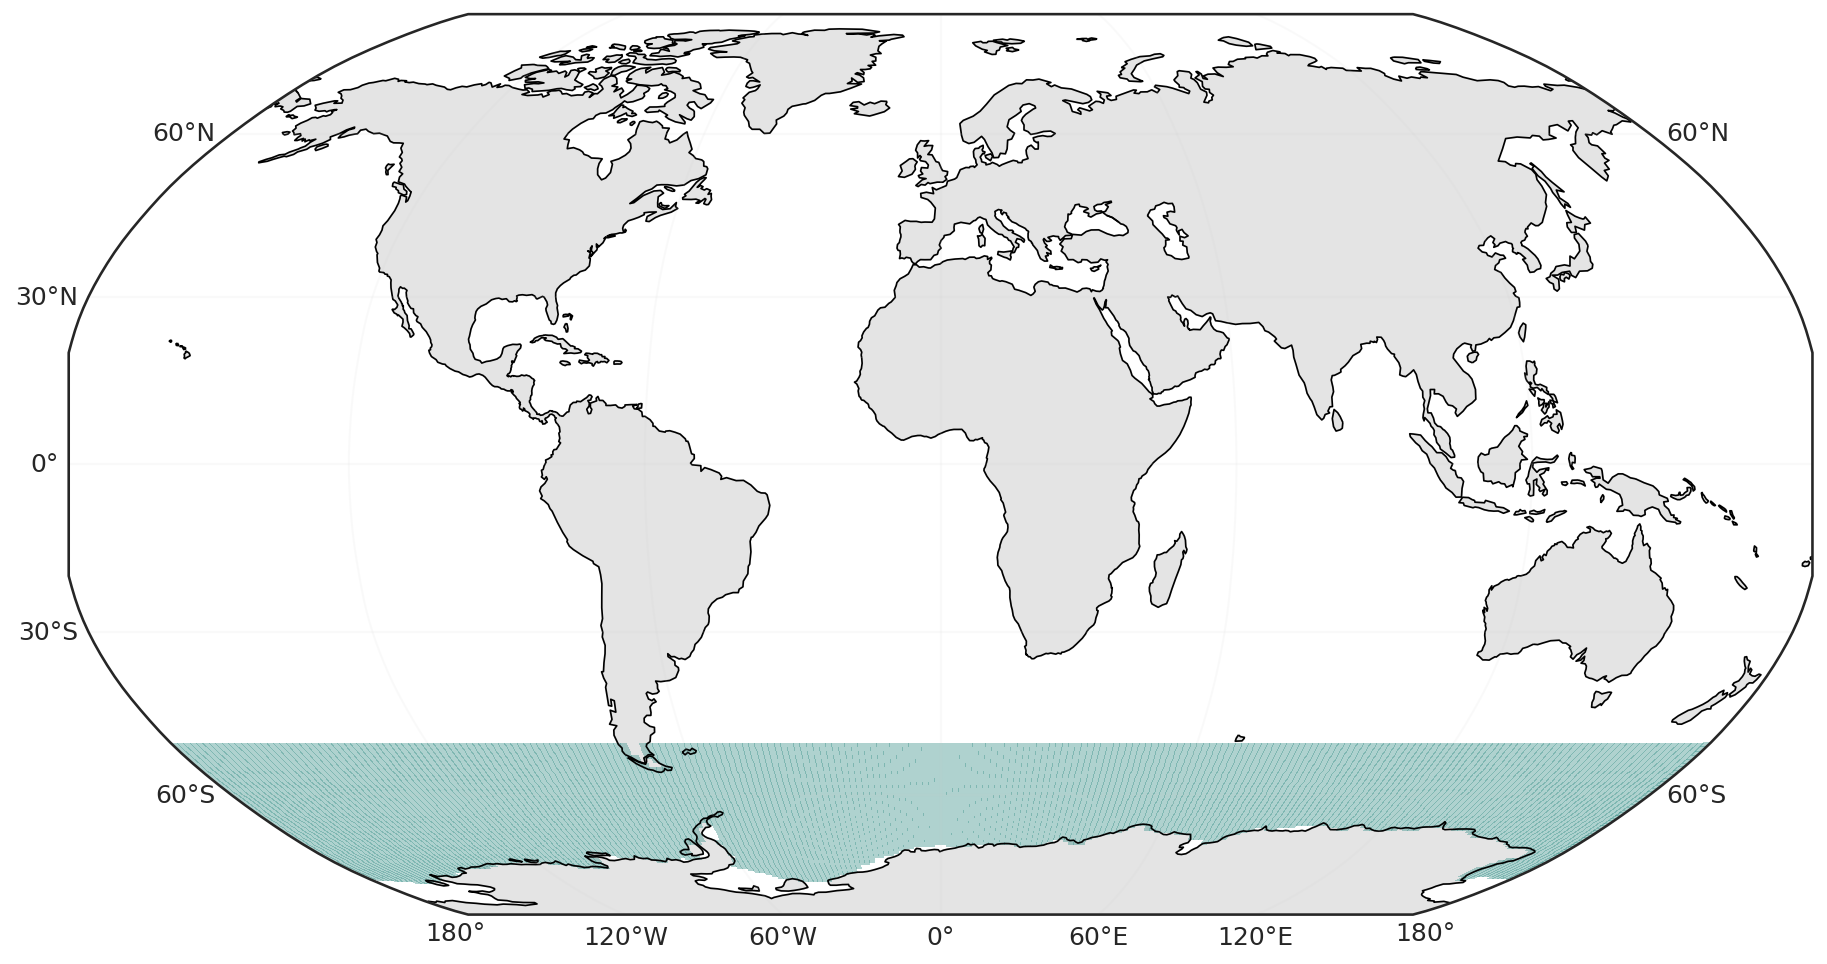

In [5]:
import matplotlib.colors as colors

# Create binary norm
boundaries = [-0.5, 0.5, 1.5]  # Creates bins: [-0.5, 0.5) and [0.5, 1.5]

# Alternative if your data has negative values:
# boundaries = [-1., 0., 1.]

# Create binary norm
binary_norm = colors.BoundaryNorm(boundaries, ncolors=2)

# Create binary colormap with alpha
binary_cmap_rgba = colors.ListedColormap([
    (1.0, 1.0, 1.0, 0.0),   # Completely transparent for value 0
    (55/255, 143/255, 136/255, 0.4)    # Solid red for value 1 (only visible values)
])

fig, ax = plt.subplots(1, 1, figsize = (15, 10),
                        subplot_kw={'projection': ccrs.Robinson()})
ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())

cm = ax.pcolormesh(ds['geolon'].compute(), ds['geolat'].compute(), 
                   (ds['mask'] *  (ds['wet'] > 0)).compute(), 
                   cmap=binary_cmap_rgba,
                   norm = binary_norm,
                   transform=ccrs.PlateCarree())
# Add gridlines for PlateCarree projection
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha = 0.1)
gl.top_labels = False
gl.right_labels = False

# Add geographic features (these will show through transparent areas)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='black')
ax.add_feature(cfeature.LAND, alpha=0.6, color='lightgray')